Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_382\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_385\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_386\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_388\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_389\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_390\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_401\track.csv
Skipping EMPTY track: C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi\warm_sst\run_409\tr

C:\Users\ketan\AppData\Local\Temp\ipykernel_23692\304626403.py:62: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf["dist_km"] = gdf_3857.geometry.distance(coast_3857.unary_union) / 1000.0


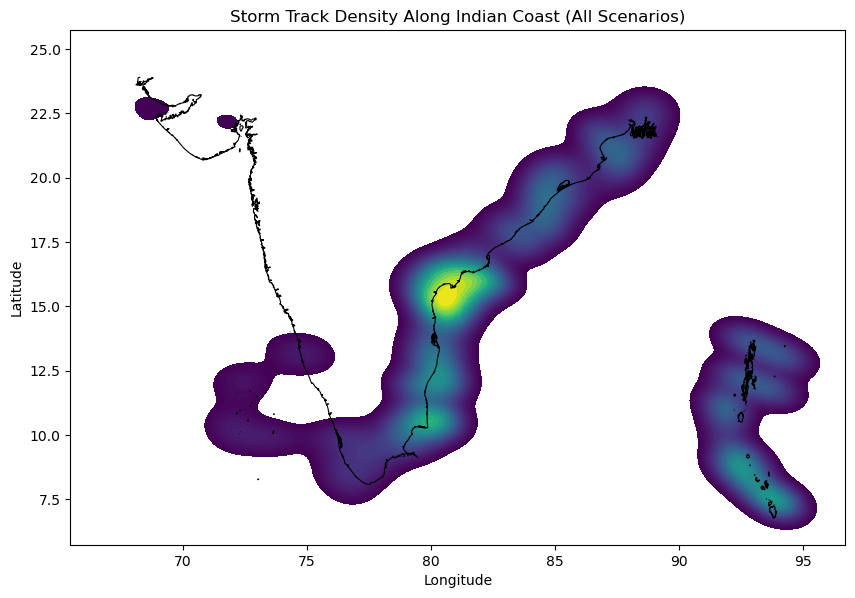

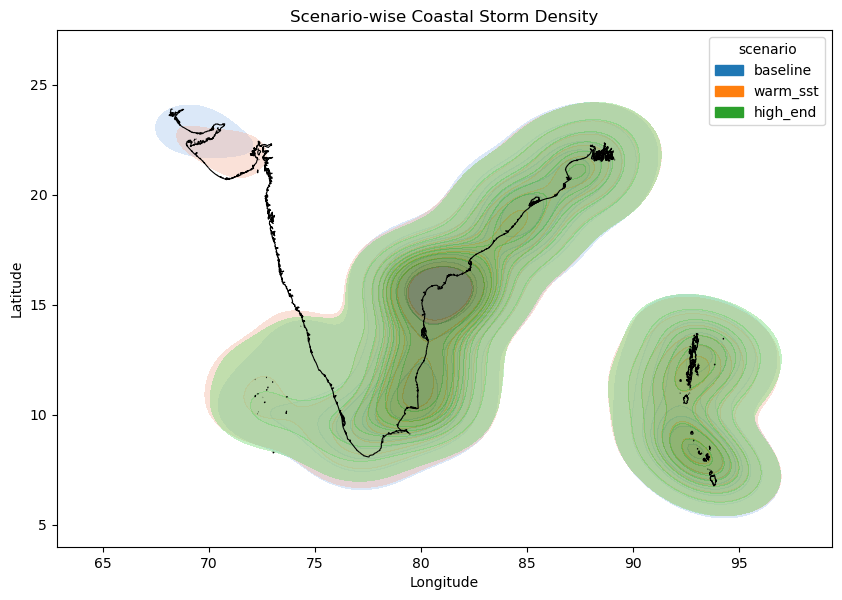

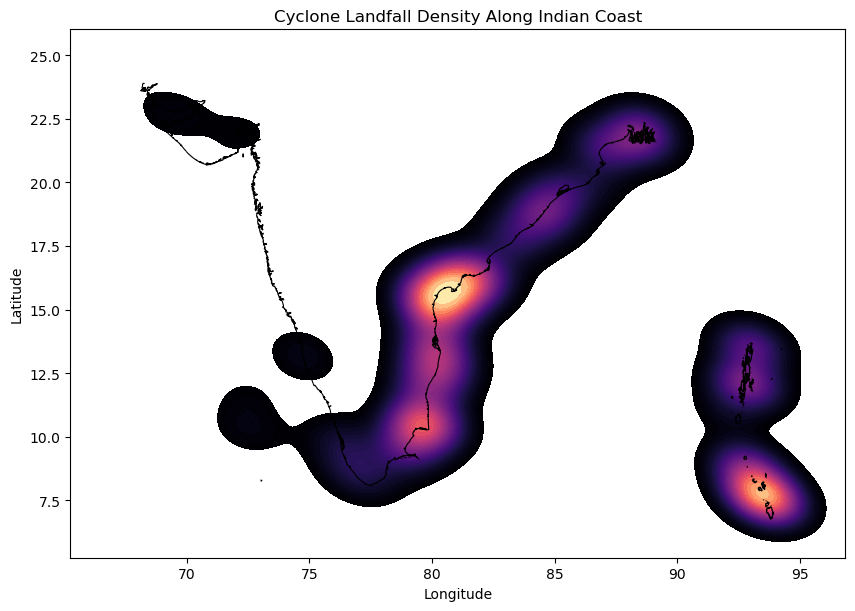

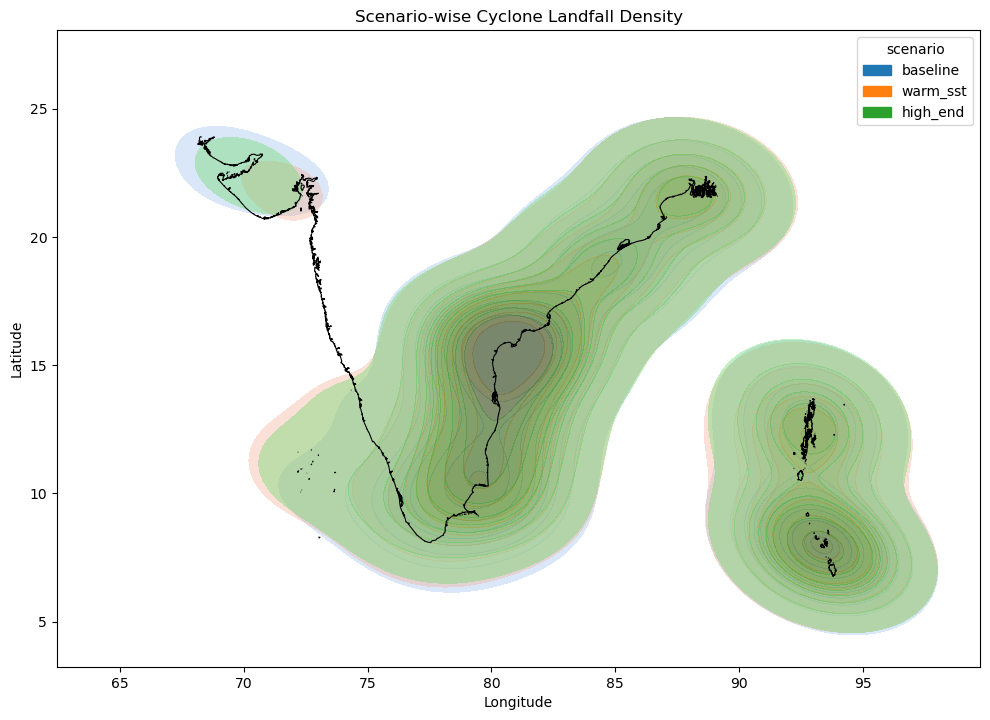

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Load all track points
# ---------------------------------------------------------
BASE = r"C:\CMIP data\cmip6\Climada\Projects\ccart-india\outputs\synthetic_runs_multi"
SCENARIOS = ["baseline", "warm_sst", "high_end"]

all_points = []

for scen in SCENARIOS:
    scen_dir = os.path.join(BASE, scen)
    for run in os.listdir(scen_dir):
        run_dir = os.path.join(scen_dir, run)
        track_path = os.path.join(run_dir, "track.csv")

        if not os.path.exists(track_path):
            continue

        if os.path.getsize(track_path) == 0:
            print("Skipping EMPTY track:", track_path)
            continue

        try:
            df_track = pd.read_csv(track_path)
        except pd.errors.EmptyDataError:
            print("Skipping unreadable track:", track_path)
            continue

        if not {"lat", "lon"}.issubset(df_track.columns):
            print("Skipping track with missing lat/lon:", track_path)
            continue

        for lat, lon in zip(df_track["lat"], df_track["lon"]):
            all_points.append({"scenario": scen, "lat": lat, "lon": lon})

# ---------------------------------------------------------
# Build GeoDataFrame in degrees (EPSG:4326)
# ---------------------------------------------------------
gdf = gpd.GeoDataFrame(
    all_points,
    geometry=gpd.points_from_xy([p["lon"] for p in all_points],
                                [p["lat"] for p in all_points]),
    crs="EPSG:4326"
)

# Load coastline
coast = gpd.read_file(r"C:\CMIP data\cmip6\Climada\Projects\ccart-india\data\coastl_ind.shp")
coast = coast.to_crs("EPSG:4326")

# ---------------------------------------------------------
# Compute distance to coast (in meters)
# ---------------------------------------------------------
gdf_3857 = gdf.to_crs("EPSG:3857")
coast_3857 = coast.to_crs("EPSG:3857")

gdf["dist_km"] = gdf_3857.geometry.distance(coast_3857.unary_union) / 1000.0

# Coastal points (within 100 km)
coastal_deg = gdf[gdf["dist_km"] <= 100].copy()

# ---------------------------------------------------------
# Identify landfall points (points inside India polygon)
# ---------------------------------------------------------
india_poly = gpd.read_file(
    r"C:\CMIP data\cmip6\Climada\Country Shape Files\India\india_India_Country_Boundary.shp"
).to_crs("EPSG:4326")

india = india_poly.dissolve()

gdf["on_land"] = gdf.within(india.geometry.iloc[0])
# Landfall = points within 20 km of coast
landfall_points = gdf[gdf["dist_km"] <= 20].copy()

# ---------------------------------------------------------
# Plot 1: Track density (all scenarios)
# ---------------------------------------------------------
plt.figure(figsize=(10, 12))
sns.kdeplot(
    data=coastal_deg,
    x="lon",
    y="lat",
    fill=True,
    cmap="viridis",
    bw_adjust=0.5,
    levels=50,
    thresh=0.05
)
coast.plot(ax=plt.gca(), color="black", linewidth=0.8)
plt.title("Storm Track Density Along Indian Coast (All Scenarios)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ---------------------------------------------------------
# Plot 2: Scenario-wise track density
# ---------------------------------------------------------
plt.figure(figsize=(10, 12))
sns.kdeplot(
    data=coastal_deg,
    x="lon",
    y="lat",
    hue="scenario",
    fill=True,
    alpha=0.4
)
coast.plot(ax=plt.gca(), color="black", linewidth=0.8)
plt.title("Scenario-wise Coastal Storm Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# ---------------------------------------------------------
# Plot 3: Landfall density (all scenarios)
# ---------------------------------------------------------
plt.figure(figsize=(10, 12))
sns.kdeplot(
    data=landfall_points,
    x="lon",
    y="lat",
    fill=True,
    cmap="magma",
    bw_adjust=0.6,
    levels=40,
    thresh=0.05
)
coast.plot(ax=plt.gca(), color="black", linewidth=0.8)
plt.title("Cyclone Landfall Density Along Indian Coast")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


# ---------------------------------------------------------
# Plot 4: Scenario-wise landfall density
# ---------------------------------------------------------
plt.figure(figsize=(10, 12))
sns.kdeplot(
    data=landfall_points,
    x="lon",
    y="lat",
    hue="scenario",
    fill=True,
    alpha=0.4
)
coast.plot(ax=plt.gca(), color="black", linewidth=0.8)
plt.title("Scenario-wise Cyclone Landfall Density")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(
    r"C:\CMIP data\cmip6\Climada\Projects\ccart-india\examples\scenario_wise_landfall_density.png",
    dpi=300,
    bbox_inches="tight",
    facecolor='white'
)
plt.show()
